# Honours Research Part 1: Preliminary Research/Coding
## Objective:
Replicating "A novel epileptic seizure prediction method based on synchroextracting transform and 1-dimensional convolutional neural network" by Ra et al. (2023).

### Load EEG files and montages

Extracting EDF parameters from chb02/chb02_01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from chb02/chb02_19.edf...
Setting channel info structure...
Creating raw.info structure...
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2074-07-24 15:29:39 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


C:\Users\Mary Yap\AppData\Local\Temp\ipykernel_36460\1150330666.py:4: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf("chb02/chb02_01.edf")
C:\Users\Mary Yap\AppData\Local\Temp\ipykernel_36460\1150330666.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  pre_ictal = mne.io.read_raw_edf("chb02/chb02_19.edf")


Using matplotlib as 2D backend.


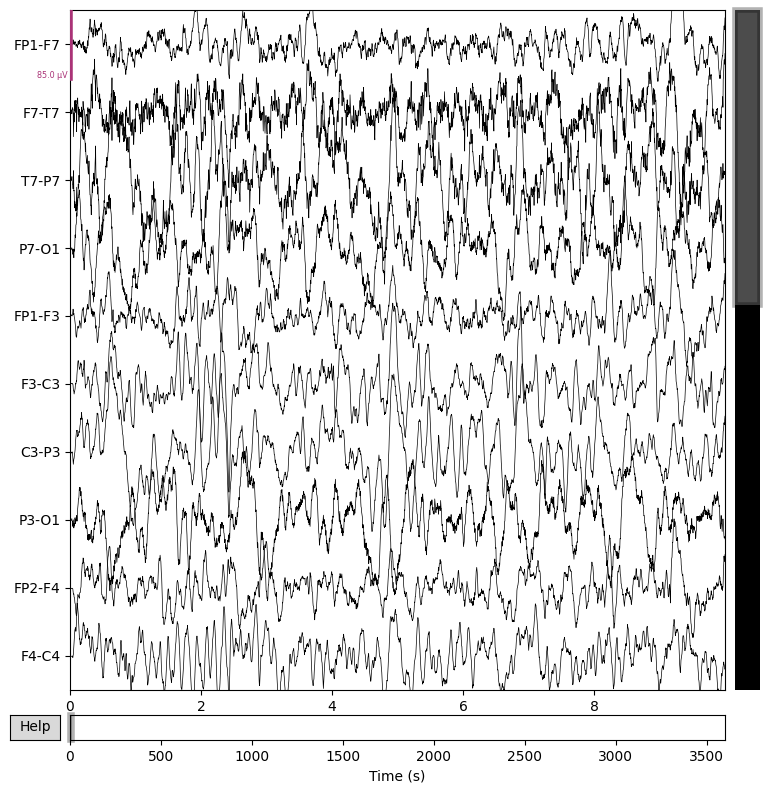

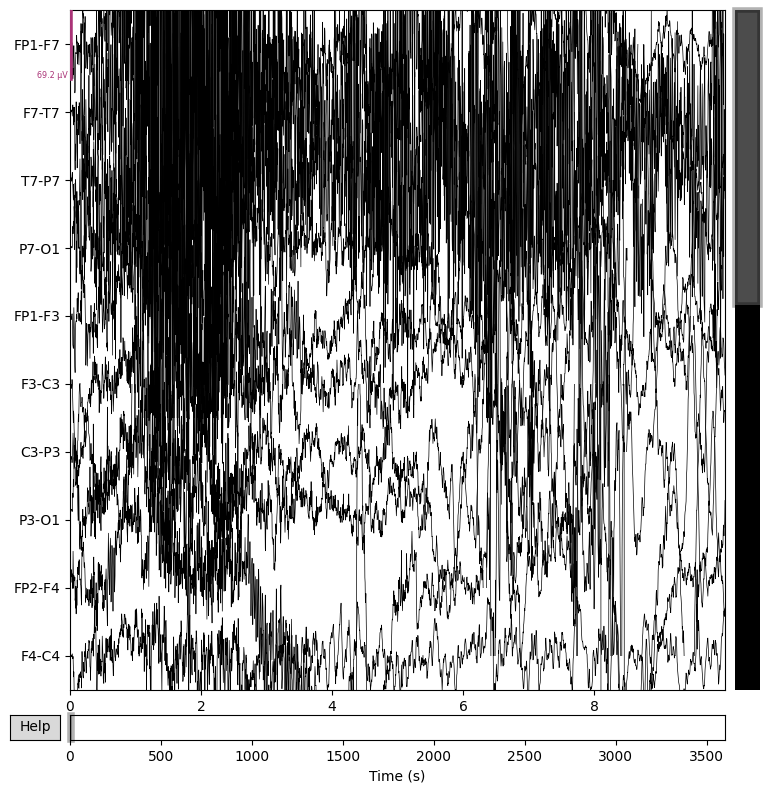

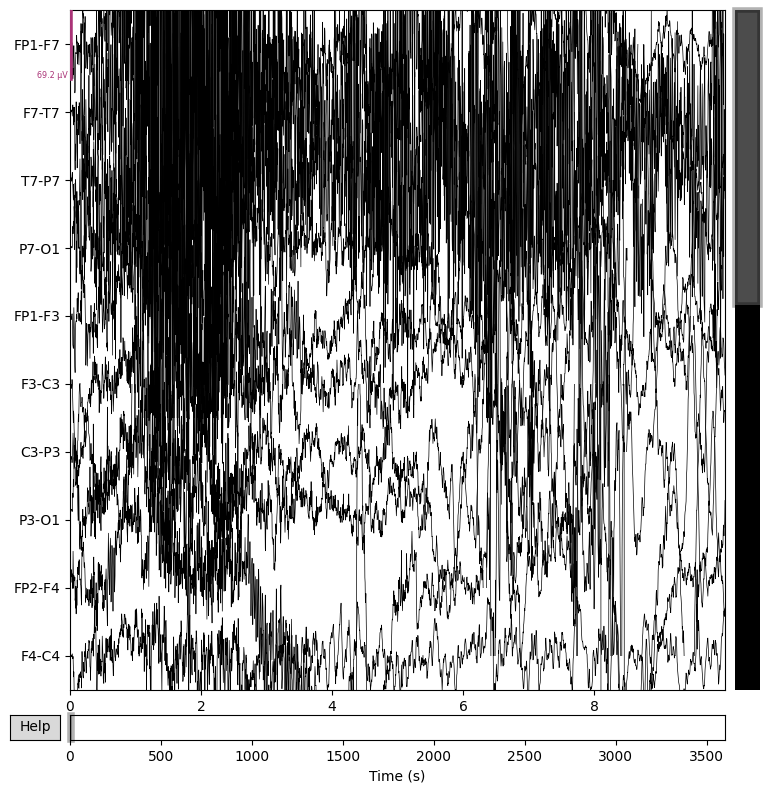

In [1]:
import mne

# Load files from CHB-MIT Database
raw = mne.io.read_raw_edf("chb02/chb02_01.edf")
pre_ictal = mne.io.read_raw_edf("chb02/chb02_19.edf")

# Print metadata
print(raw.info)

# Print channel names
print(raw.ch_names)

# Plot graphs
raw.plot(duration=10, n_channels=10, scalings='auto')
pre_ictal.plot(duration=10, n_channels=10, scalings='auto')

### Extract 2.8 second clips from normal and pre-ictal periods (10:1 ratio)

In [6]:
import numpy as np
import random

# Configure frequency, window duration, etc.
sampling_rate = 256
duration = 2.8 # seconds
clip_length = int(sampling_rate * duration) # 716 samples
total_seconds_in_hour = 3600 

normal_clips_list = []

# Extract 10 normal clips
for _ in range(10):
    # Pick a random second between 0 and 3590
    start_sec = random.randint(0, total_seconds_in_hour - 10)
    
    start_sample = int(start_sec * sampling_rate)
    stop_sample = start_sample + clip_length
    
    # Grab the data for ALL channels (or just channel 0)
    chunk = raw.get_data(start=start_sample, stop=stop_sample)
    normal_clips_list.append(chunk)

# Convert list to 3D numpy array: (Number of clips, Channels, Samples)
X_normal = np.array(normal_clips_list)

print(f"Normal clip array shape: {X_normal.shape}") # Check

# Define seizure window
seizure_start = 3369
sph = seizure_start - 600  # 2769

# Convert to samples from seconds
start_pre_ictal = int(sph * sampling_rate)
stop_pre_ictal = start_pre_ictal + clip_length

# Extract pre-ictal clip
pre_ictal_clip = pre_ictal_data[0, start_pre_ictal:stop_pre_ictal]

print(f"Pre-ictal clip shape: {pre_ictal_clip.shape}") # Check

Normal clip array shape: (10, 23, 716)
Pre-ictal clip shape: (716,)


### Create overlapping windows

In [34]:
# Create overlapping windows of length=10, step=5
def moving_window(data, window_size, step_size):
    num_points = len(data)
    window_length = window_size # Length of window in samples
    step_length = step_size # Length of step in samples
    windows = []
    for start in range(0, num_points - window_length + 1, step_length):
        windows.append(data[start:start + window_length])
    return np.array(windows)

window_size = 10 # Length of window (samples)
step_size = 5 # Length of step (samples)

# Create overlapping windows for all 10 normal clips
normal_windows = {}
for i in range(10):
    windows = moving_window(X_normal[i, 0, :], window_size, step_size)
    normal_windows[f"clip_{i}"] = windows

# Create overlapping windows for pre-ictal clip
pre_ictal_windows = moving_window(pre_ictal_clip, window_size, step_size)

print(normal_windows["clip_2"]) # Check
print(pre_ictal_windows) # Check

[[-1.19169719e-05 -2.36385836e-05 -9.57264957e-06 ... -3.14529915e-05
  -2.87179487e-05 -1.85592186e-05]
 [ 9.57264957e-06  1.46520147e-05 -3.14529915e-05 ...  9.57264957e-06
   1.89499389e-05  2.52014652e-05]
 [-2.24664225e-05  2.14896215e-06  9.57264957e-06 ... -1.73870574e-05
  -1.54334554e-05 -1.36752137e-06]
 ...
 [ 2.48107448e-05  2.44200244e-05 -2.40293040e-05 ...  2.20757021e-05
   2.28571429e-05  5.66544567e-06]
 [-2.87179487e-05  8.79120879e-06  2.20757021e-05 ...  7.61904762e-06
   5.66544567e-06  1.66056166e-05]
 [-2.14896215e-06 -4.10256410e-06  7.61904762e-06 ...  1.23076923e-05
   1.85592186e-05  1.19169719e-05]]
[[-1.34798535e-05 -2.12942613e-05 -1.66056166e-05 ... -4.31746032e-05
  -5.91941392e-05 -6.27106227e-05]
 [ 4.78632479e-05  4.88400488e-06 -4.31746032e-05 ...  2.75457875e-05
   2.87179487e-05  1.93406593e-05]
 [-3.65323565e-05  8.00976801e-06  2.75457875e-05 ... -3.92673993e-05
  -2.55921856e-05 -1.93406593e-05]
 ...
 [ 9.96336996e-06  1.58241758e-05  1.9340659